# Single Image INR Step vs Test Loss

[     _step  test_loss Sampling Rate
0        0  11.675028         0.001
1       10  11.525255         0.001
2       20  11.267922         0.001
3       30  10.926170         0.001
4       40  10.709990         0.001
..     ...        ...           ...
495   4960   0.397721         0.001
496   4970   0.420144         0.001
497   4980   0.441940         0.001
498   4990   0.459512         0.001
499   4999   0.437012         0.001

[500 rows x 3 columns],      _step  test_loss Sampling Rate
0        0  11.627566         0.005
1       10  10.968001         0.005
2       20  10.443110         0.005
3       30   9.810792         0.005
4       40   9.242895         0.005
..     ...        ...           ...
495   4960   0.123000         0.005
496   4970   0.149919         0.005
497   4980   0.121388         0.005
498   4990   0.128348         0.005
499   4999   0.110488         0.005

[500 rows x 3 columns],      _step  test_loss Sampling Rate
0        0  11.595575          0.01
1       10  1

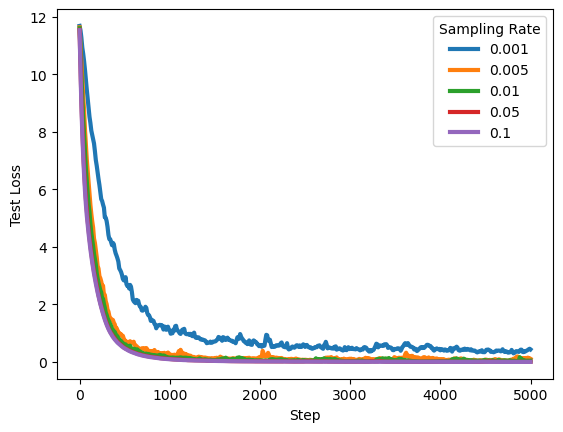

In [39]:
import wandb
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("skmccue/inr-sampling-single-5000")
hist_list = [] 
for run in runs: 
    if not 'test_loss' in run.summary or 'random_' not in run.name:
        continue
    # print("Run\n",str(run.history))
    sampling_rate = run.name.split("random_")[1].split("_")[0]
    hist = run.history(keys=['_step', 'test_loss'])
    # print(list(hist['test_loss']))
    hist['Sampling Rate'] = sampling_rate
    hist_list.append(hist)
print(hist_list)
# values = ','.join(str(v) for v in hist_list[0]['_step'])
# print(values)
# print(hist_list)
# print(list(hist['test_loss']))
# print(','.join(str(v) for v in list(hist['test_loss'])))

df = pd.concat(hist_list, ignore_index=True)
df = df.query("`test_loss` != 'NaN'")

ax = sns.lineplot(x="_step", y="test_loss", hue="Sampling Rate", data=df)
ax.set_xlabel("Step")
ax.set_ylabel("Test Loss")

plt.show()

# with open('/sdcc/u/smccue/projects/inr_sampling/visuals/out.txt', 'w') as f:
#     print(values, file=f)  # Python 3.x


# Single Image INR Sampling Rate vs Best Test Loss

In [8]:
import wandb
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["lines.linewidth"] = 3.0

api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("skmccue/inr-sampling-single-500")
hist_list = [] 
for run in runs: 
    if not 'test_loss' in run.summary:
        continue

    sample_type = run.name.split("_")[-5]
    sampling_rate = run.name.split("_")[-4]
    hist = run.history(keys=['_step', 'test_loss'])
    hist['Sample Type'] = sample_type
    hist['test_loss'] = hist['test_loss'].min()
    hist['Sampling Rate'] = sampling_rate

    if sample_type == "null":
        full_loss = hist['test_loss'].min()
        continue

    
    hist_list.append(hist)

df = pd.concat(hist_list, ignore_index=True)
df = df.query("`test_loss` != 'NaN'")



ax = sns.lineplot(x="Sampling Rate", y="test_loss", data=df, hue="Sample Type",
                  linewidth = 1.5)

ax.axhline(
    full_loss,
    color="gray",
    linestyle="--",
    linewidth=2,
    label="full training"
)

ax.set_xlabel("Sampling Rate")
ax.set_ylabel("Best Test Loss")


leg = ax.legend()
leg_lines = leg.get_lines()
leg_lines[4].set_linestyle(":")


plt.show()



ValueError: Could not find project inr-sampling-single-500